In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("1-studyhours.csv")
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  33 non-null     float64
 1   Exam Score   33 non-null     float64
dtypes: float64(2)
memory usage: 660.0 bytes


In [12]:
df.describe()

,Study Hours,Exam Score
count,33.000000,33.000000
mean,15.772727,74.612121
std,7.608723,18.711206
min,3.000000,40.000000
25%,9.600000,58.500000
50%,17.400000,78.800000
75%,21.300000,90.800000
max,30.000000,100.000000


In [13]:
df.isnull().sum()

Study Hours    0
Exam Score     0
dtype: int64

In [14]:
df["Exam Score"].value_counts()

Exam Score
40.0     1
57.1     1
42.7     1
65.1     1
78.7     1
78.8     1
77.1     1
90.8     1
99.0     1
84.6     1
92.4     1
95.9     1
92.0     1
100.0    1
86.6     1
97.0     1
57.2     1
74.7     1
64.9     1
84.7     1
49.0     1
58.5     1
76.5     1
42.2     1
51.2     1
42.4     1
64.8     1
79.5     1
79.1     1
82.4     1
91.5     1
96.2     1
89.6     1
Name: count, dtype: int64

In [15]:
df["Study Hours"].value_counts()

Study Hours
9.6     3
3.9     2
14.4    2
25.2    2
17.4    2
21.3    2
17.7    2
4.5     1
11.4    1
18.0    1
19.2    1
22.2    1
26.1    1
30.0    1
27.3    1
21.0    1
5.7     1
12.9    1
8.1     1
3.0     1
5.1     1
15.6    1
19.5    1
23.4    1
18.9    1
Name: count, dtype: int64

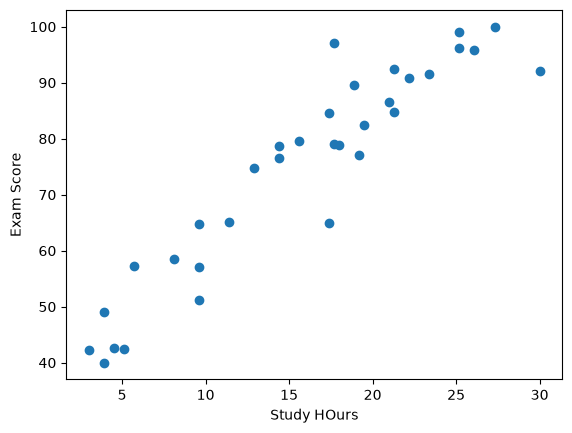

In [17]:
plt.scatter(df["Study Hours"],df["Exam Score"])
plt.xlabel("Study HOurs")
plt.ylabel("Exam Score")
plt.show()

# independent and dependent feature

In [18]:
X=df["Study Hours"]
y=df["Exam Score"]

In [23]:
type(X)

pandas.Series

# Regresion gibi makine öğrenmesi algoritmalarında X gibi girdileri dataframe olarak vermemizi ister. Bunun sebebi girdi bilgilerinin birden fazla olması.
# o yüzden X'i tanımlarken iki kez köşeli paranteze almamız gerekmektedir.

In [24]:
type(y)

pandas.Series

# y ise tek bir çıktı olacağı için series ister

In [27]:
X=df[["Study Hours"]]
y=df["Exam Score"]

In [29]:
type(X)

pandas.DataFrame

In [30]:
type(y)

pandas.Series

# test - train split

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_text, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=15)

In [38]:
y_train

18     64.9
1      57.1
2      42.7
32     89.6
6      77.1
3      65.1
29     82.4
26     64.8
9      84.6
4      78.7
28     79.1
10     92.4
27     79.5
13    100.0
17     74.7
15     97.0
22     76.5
31     96.2
11     95.9
7      90.8
0      40.0
23     42.2
5      78.8
12     92.0
21     58.5
8      99.0
Name: Exam Score, dtype: float64

In [35]:
y_test

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

# standardize the data set --> 

In [39]:
from sklearn.preprocessing import StandardScaler 

# balanced feature values
# efficient gradient descent
# l1, l2

In [40]:
scaler = StandardScaler()

In [41]:
X_train = scaler.fit_transform(X_train)
X_text = scaler.transform(X_text)

In [42]:
X_train

array([[ 0.11794385],
       [-0.97424848],
       [-1.68837424],
       [ 0.32798083],
       [ 0.36998823],
       [-0.7222041 ],
       [ 0.41199563],
       [-0.97424848],
       [ 0.11794385],
       [-0.30213013],
       [ 0.15995124],
       [ 0.66404001],
       [-0.13410054],
       [ 1.50418796],
       [-0.51216711],
       [ 0.15995124],
       [-0.30213013],
       [ 1.21013618],
       [ 1.33615837],
       [ 0.7900622 ],
       [-1.77238903],
       [-1.89841122],
       [ 0.20195864],
       [ 1.88225453],
       [-1.18428547],
       [ 1.21013618]])

In [43]:
X_text

array([[-1.60435944],
       [ 0.62203261],
       [ 0.95809179],
       [-1.52034465],
       [-0.97424848],
       [-1.77238903],
       [ 0.66404001]])

# REGRESYON MODELİNİ EĞİTMEK

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
regression = LinearRegression()

In [46]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[16.18]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,76.91
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5.1]


In [47]:
print("Coofficient: ",regression.coef_)
print("Intercept :",regression.intercept_)

Coofficient:  [16.17860223]
Intercept : 76.9076923076923


# y = 76.91 + 16.18x --> denklem bu. Burada x yerine çalışma saati verirsek bize sınavdan kaç alacağımızı söylüyor. örneğin sıfır (0) saat çalışırsak 76.91 + 16.18*0 dan 76.91 alacağımızı söylüyor.

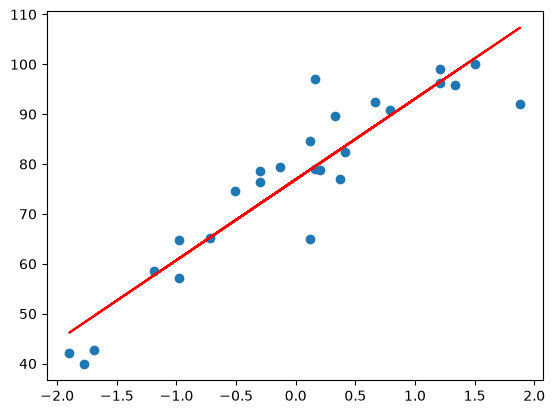

In [48]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),"r")
plt.show()

In [ ]:
# 20 saat çalışmış insanın sınavdan kaç alır

In [49]:
regression.predict([[20]])

array([400.47973694])

In [50]:
scaler.transform([[20]])

/home/ares/Desktop/Yazilimlar/Yapayzeka/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.48200796]])

In [51]:
regression.predict(scaler.transform([[20]]))

/home/ares/Desktop/Yazilimlar/Yapayzeka/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([84.70590731])

In [ ]:
# REGRESYON BAŞARI METRİKLERİ
"""
Başarıyı neye göre ölçeceğiz bunu anlamaız gerekiyor burada R-kare (R Suquare) ve Adjusted Rsquare kullanacağız
"""

In [ ]:
# Prediction with test data

In [52]:
regression.predict(X_text)

array([50.95139904, 86.97131054, 92.40827832, 52.31064098, 61.14571361,
       48.23291515, 87.65093152])

In [53]:
X_text

array([[-1.60435944],
       [ 0.62203261],
       [ 0.95809179],
       [-1.52034465],
       [-0.97424848],
       [-1.77238903],
       [ 0.66404001]])

In [54]:
y_pred_test = regression.predict(X_text)

In [55]:
y_test

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

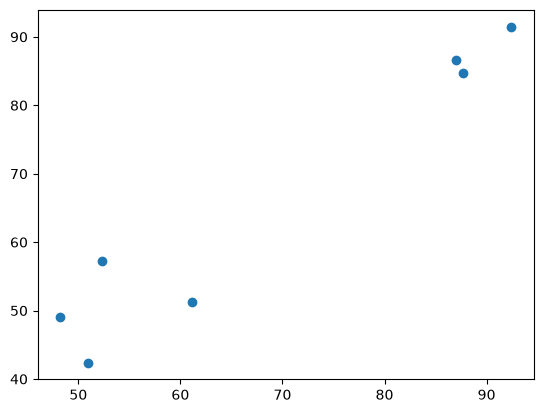

In [ ]:
plt.scatter(y_pred_test,y_test)
plt.show()

In [57]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [58]:
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)

print("mse :",mse)
print("mae :",mae)
print("rmse :",rmse)

mse : 29.45839048833392
mae : 4.054868128856142
rmse : 5.427558427906043


In [59]:
r2 = r2_score(y_test,y_pred_test)
print("r2 score :",r2)

r2 score : 0.9196596206825491


In [ ]:
#adjusted r2 score
1 -(1-r2) * (len(y_test)-1)/(len(y_test) - X_text.shape[1]-1)

0.903591544819059